In [1]:
import xarray as xr
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

In [2]:

path_T = Path("..") / "data" / "T_southamerica_base_period_historic_local.nc"
path_P = Path("..") / "data" / "P_southamerica_base_period_historic_local.nc"

In [3]:
T = xr.load_dataset(path_T)
P = xr.load_dataset(path_P)

# Bioclim1

In [4]:
def MAT(T):
    """
    Calculate Mean Annual Temperature (MAT) averages (bio1).

    Parameters:
    T (xarray.Dataset): Dataset containing monthly temperature data (for one 30-year average year) with variable 'Tavg' for average temperature.
                        Expected dimensions are (month, latitude, longitude).

    P (xarray.Dataset): Dataset containing precipitation data with variable "pr" for total monthly precipitaiton in mm. 
                        Expected dimensions are (month, latitude, longitude).

    Returns:
    xarray.DataArray: Mean Annual Temperature (MAT),
                      Dimensions are (latitude, longitude).
    """
    # Calculate mean annual temperature
    bio1 = T.Tavg.mean(dim="month")

    return bio1.rename("MAT")

In [5]:
bio1 = MAT(T)

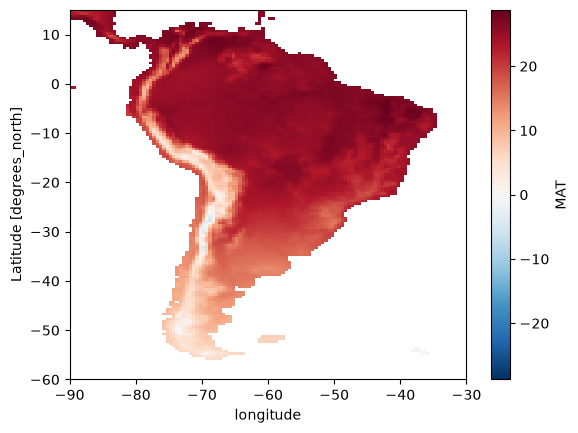

In [6]:
bio1.plot()

# Bioclim4

In [7]:
def TS(T):
    """
    Calculate Temperature Seasonality (TS) (bio4).

    Parameters:
    T (xarray.Dataset): Dataset containing temperature data with variable 'Tavg' for average temperature.
                        Expected dimensions are (time, latitude, longitude).


    Returns:
    xarray.DataArray: Temperature Seasonality (TS) calculated as the standard deviation of monthly temperatures for 30 average year.
    Dimensions are (latitude, longitude).

    """
    bio4 = T.Tavg.std(dim="month")

    return bio4.rename("TS")

c:\Users\Clemens\Anaconda\envs\amazon_tip_project\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


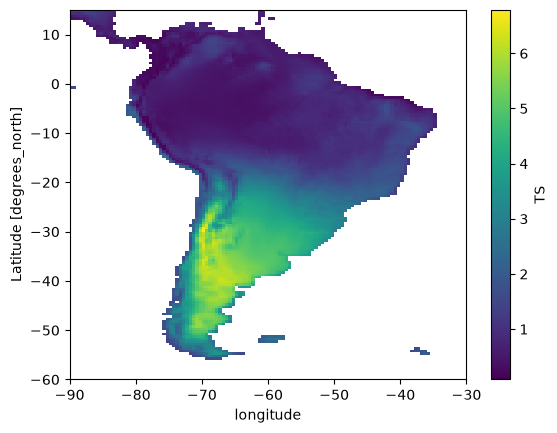

In [8]:
bio4= TS(T)
bio4.plot()

# Bioclim8

In [9]:
def MTWeQ(T,P):
    """
    Calculate Mean temperature of the wettest quarter (bio8)
    
    Parameters:
    T (xarray.Dataset): Dataset containing temperature data with variable 'Tavg' for average monthly temperature.
                        Expected dimensions are (month, latitude, longitude).
    P (xarray.Dataset): Dataset containing precipitation data with variable "pr" for total monthly precipitaiton in mm. 
                        Expected dimensions are (month, latitude, longitude).
    
    Returns:
    xarray.DataArray: Mean temperature of the wettest quarter (MTWeQ) calculated by first identifying the quarter of maximal precipitation 
                      in the year and secondly calculating the temperature mean for that quarter. Dimensions are (latitude, longitude).
                      
    """
    
    # Determine the precipitation variable name (depends on scenario)
    pr_name = list(P.data_vars)[0]

    # Douple the P datset along the time axis (month) to enable rolling calculation (numerate month up to 24)
    P_douple = xr.concat([P, P], dim="month")
    P_douple = P_douple.assign_coords(month=np.arange(1, 25))

    T_douple = xr.concat([T, T], dim="month")
    T_douple = T_douple.assign_coords(month=np.arange(1, 25))
    
    # Calculate rolling sum over 3 months (quarterly sum) and shift by -1 to get the correct month 
    P_rolling = P_douple.rolling(month=3, center=True).sum().shift(month=-1).sel(month=np.arange(1,13))
    # Calculate rolling mean over 3 months (quarterly mean) and shift by -1 to get the correct month
    T_rolling = T_douple.rolling(month=3, center=True).mean().shift(month=-1).sel(month=np.arange(1,13))

    # Get the month index of the wettest quarter
    max_months = P_rolling.idxmax(dim="month").fillna(1).astype(int)

    # Select the temperature mean of the wettest quarter
    T_select = T_rolling.sel(month=max_months[pr_name])

    return T_select.Tavg.rename("MTWeQ")



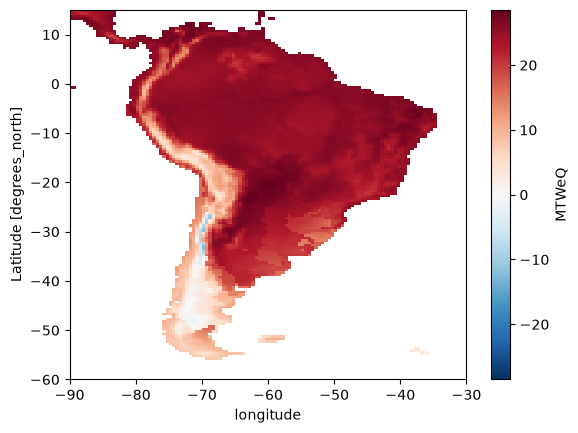

In [10]:
bio8 = MTWeQ(T,P)
bio8.plot()

# Bioclim9 

In [11]:
def MTDQ(T,P):
    """
    Calculate Mean temperature of the driest quarter (bio9)
    
    Parameters:
    T (xarray.Dataset): Dataset containing temperature data with variable 'Tavg' for average monthly temperature.
                        Expected dimensions are (month, latitude, longitude).
    P (xarray.Dataset): Dataset containing precipitation data with variable "pr" for total monthly precipitaiton in mm. 
                        Expected dimensions are (month, latitude, longitude).
    
    Returns:
    xarray.DataArray: Mean temperature of the driest quarter (MTDQ) calculated by first identifying the quarter of minimal precipitation 
                      in the year and secondly calculating the temperature mean for that quarter. Dimensions are (latitude, longitude).
                      
    """
    
    # Determine the precipitation variable name (depends on scenario)
    pr_name = list(P.data_vars)[0]

    # Douple the P datset along the time axis (month) to enable rolling calculation (numerate month up to 24)
    P_douple = xr.concat([P, P], dim="month")
    P_douple = P_douple.assign_coords(month=np.arange(1, 25))

    T_douple = xr.concat([T, T], dim="month")
    T_douple = T_douple.assign_coords(month=np.arange(1, 25))
    
    # Calculate rolling sum over 3 months (quarterly sum) and shift by -1 to get the correct month 
    P_rolling = P_douple.rolling(month=3, center=True).sum().shift(month=-1).sel(month=np.arange(1,13))
    # Calculate rolling mean over 3 months (quarterly mean) and shift by -1 to get the correct month
    T_rolling = T_douple.rolling(month=3, center=True).mean().shift(month=-1).sel(month=np.arange(1,13))

    # Get the month index of the driest quarter
    min_months = P_rolling.idxmin(dim="month").fillna(1).astype(int)

    # Select the temperature mean of the driest quarter
    T_select = T_rolling.sel(month=min_months[pr_name])

    return T_select.Tavg.rename("MTDQ")

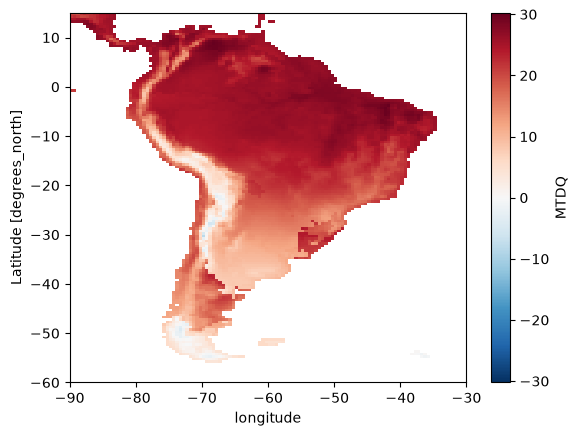

In [12]:
bio9 = MTDQ(T,P)
bio9.plot()

# Bioclim 10

In [13]:
def MTWaQ(T):
    """
    Calculate Mean temperature of the warmest quarter (bio10)
    
    Parameters:
    T (xarray.Dataset): Dataset containing temperature data with variable 'Tavg' for average monthly temperature.
                        Expected dimensions are (month, latitude, longitude).
    
    Returns:
    xarray.DataArray: Mean temperature of the warmest quarter (MTWaQ) calculated by first identifying the quarter of maximal mean temperature 
                      in the year and secondly calculating the temperature mean for that quarter. Dimensions are (latitude, longitude).
                      
    """

    var_name = list(T.data_vars)[0]
    
    T_douple = xr.concat([T, T], dim="month")
    T_douple = T_douple.assign_coords(month=np.arange(1, 25))
    
    # Calculate rolling sum over 3 months (quarterly sum) and shift by -1 to get the correct month 
    T_rolling_sum = T_douple.rolling(month=3, center=True).sum().shift(month=-1).sel(month=np.arange(1,13))
    # Calculate rolling mean over 3 months (quarterly mean) and shift by -1 to get the correct month
    T_rolling_mean = T_douple.rolling(month=3, center=True).mean().shift(month=-1).sel(month=np.arange(1,13))

    # Get the month index of the warmest quarter
    max_months = T_rolling_sum.idxmax(dim="month").fillna(1).astype(int)

    # Select the temperature mean of the warmest quarter
    T_select = T_rolling_mean.sel(month=max_months[var_name])

    # Define bio10
    bio10 = T_select.Tavg.rename("MTWaQ")

    return bio10   

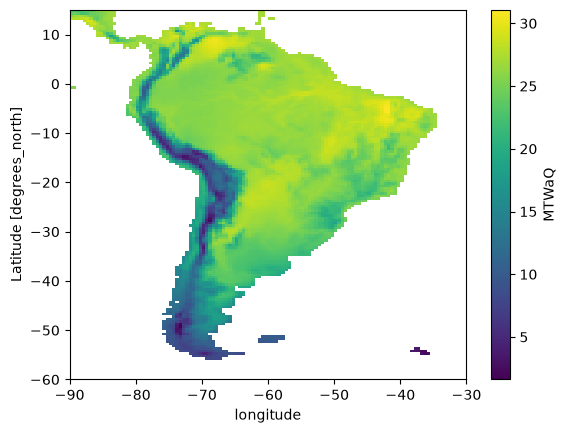

In [14]:
bio10 = MTWaQ(T)
bio10.plot()

# Bioclim 11

In [15]:
def MTCQ(T):
    """
    Calculate Mean temperature of the coldest quarter (bio11)
    
    Parameters:
    T (xarray.Dataset): Dataset containing temperature data with variable 'Tavg' for average monthly temperature.
                        Expected dimensions are (month, latitude, longitude).

    
    Returns:
    xarray.DataArray: Mean temperature of the coldest quarter (MTCQ) calculated by first identifying the quarter of minimal mean temperature 
                      in the year and secondly calculating the temperature mean for that quarter. Dimensions are (latitude, longitude).
                      
    """

    var_name = list(T.data_vars)[0]
    
    T_douple = xr.concat([T, T], dim="month")
    T_douple = T_douple.assign_coords(month=np.arange(1, 25))
    
    # Calculate rolling sum over 3 months (quarterly sum) and shift by -1 to get the correct month 
    T_rolling_sum = T_douple.rolling(month=3, center=True).sum().shift(month=-1).sel(month=np.arange(1,13))
    # Calculate rolling mean over 3 months (quarterly mean) and shift by -1 to get the correct month
    T_rolling_mean = T_douple.rolling(month=3, center=True).mean().shift(month=-1).sel(month=np.arange(1,13))

    # Get the month index of the coldest quarter
    min_months = T_rolling_sum.idxmin(dim="month").fillna(1).astype(int)

    # Select the temperature mean of the coldest quarter
    T_select = T_rolling_mean.sel(month=min_months[var_name])

    # Define bio11
    bio11 = T_select.Tavg.rename("MTCQ")

    return bio11
    

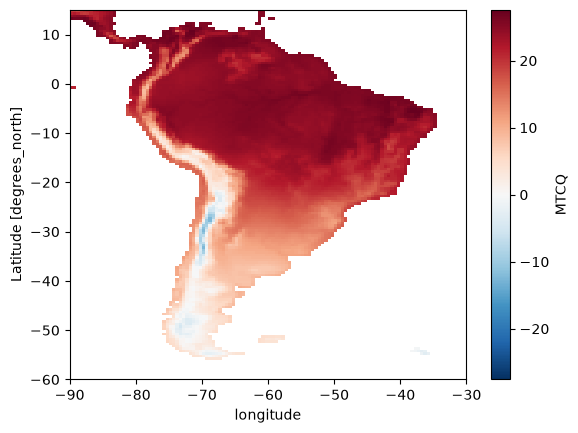

In [16]:
bio11 = MTCQ(T)
bio11.plot()

# Bioclim 12

In [17]:
def AP(P):
    """
    Calculate Annual precipitation (bio12)
    
    P (xarray.Dataset): Dataset containing precipitation data with variable "pr" for total monthly precipitaiton in mm. 
                        Expected dimensions are (month, latitude, longitude).
    
    Returns:
    xarray.DataArray: Sum of all total monthly precipitation values for 30 year average year. Dimensions are (latitude, longitude).
    """
    
    pr_name = list(P.data_vars)[0]

    # Calculate summed precipitation over each month
    P_summed = P.sum(dim="month", skipna=False)
    
    return P_summed[pr_name].rename("AP")




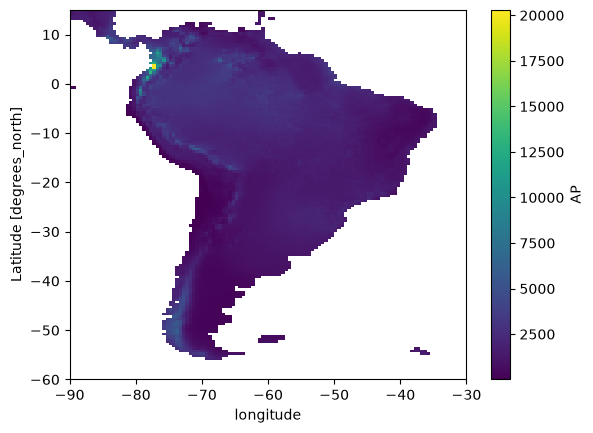

In [18]:
bio12 = AP(P)
bio12.plot()

# Bioclim13

In [19]:
def PWM(P):
    """"
    Calculate Precipitation of wettest month (bio13)

    P (xarray.Dataset): Dataset containing precipitation data with variable "pr" for total monthly precipitaiton in mm. 
                        Expected dimensions are (month, latitude, longitude).
    
    Returns:
    xarray.DataArray: precipitation of the wettest month of the 30 year average year. Dimensions are (latitude, longitude).
    """
    
    pr_name = list(P.data_vars)[0]

    # Get the month index of the wettest month
    max_months = P.idxmax(dim="month").fillna(1).astype(int)

    # Select the precipitation of the wettest month
    P_select = P.sel(month=max_months[pr_name])

    return P_select[pr_name].rename("PWM")

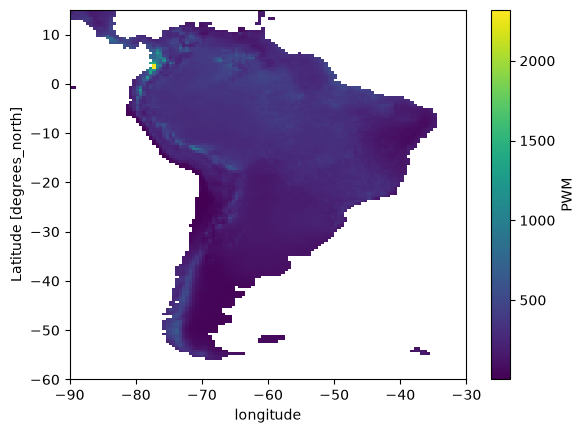

In [20]:
bio13 = PWM(P)
bio13.plot()

In [22]:
bio13.max()

<xarray.DataArray 'PWM' ()> Size: 8B
array(2318.74183075)

# Bioclim14

In [23]:
def PDM(P):
    """"
    Calculate Precipitation of driest month (bio14)

    P (xarray.Dataset): Dataset containing precipitation data with variable "pr" for total monthly precipitaiton in mm. 
                        Expected dimensions are (month, latitude, longitude).
    
    Returns:
    xarray.DataArray: precipitation of the driest month of the 30 year average year. Dimensions are (latitude, longitude).
    """
    
    pr_name = list(P.data_vars)[0]

    # Get the month index of the driest month
    min_months = P.idxmin(dim="month").fillna(1).astype(int)

    # Select the precipitation of the driest month
    P_select = P.sel(month=min_months[pr_name])

    return P_select[pr_name].rename("PDM")


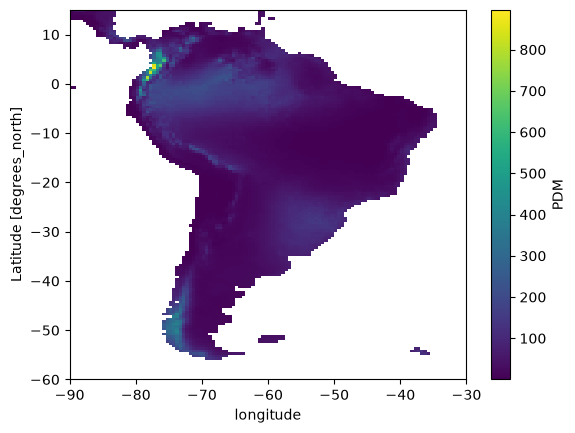

In [24]:
bio14 = PDM(P)
bio14.plot()

In [25]:
# Bioclim15

def PS(P):
    """"
    Calculate Precipitation Seasonality (bio15)

    P (xarray.Dataset): Dataset containing precipitation data with variable "pr" for total monthly precipitaiton in mm. 
                        Expected dimensions are (month, latitude, longitude).
    
    Returns:
    xarray.DataArray: Precipitation Seasonality (PS) calculated as the coefficient of variation of the monthly precipitation values. 
                      Dimensions are (latitude, longitude).
    """
    
    pr_name = list(P.data_vars)[0]

    # Calculate mean monthly precipitation
    P_mean = P.sum(dim="month", skipna=False) / 12

    # Calculate standard deviation of monthly precipitation
    P_std = P.std(dim="month", skipna=False)

    # Calculate coefficient of variation (CV)
    PS = (P_std / (1 + P_mean)) * 100

    return PS[pr_name].rename("PS")

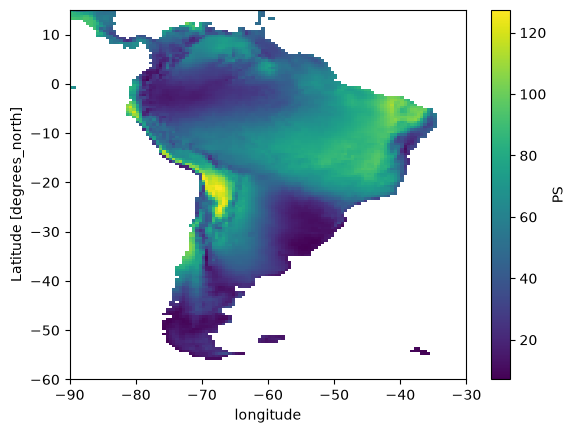

In [26]:
bio15 = PS(P)
bio15.plot()

# Bioclim16


In [27]:
def PWeQ(P):
    """
    Calculate Precipitation of the wettest quarter (bio16)
    
    Parameters:
  
    P (xarray.Dataset): Dataset containing precipitation data with variable "pr" for total monthly precipitaiton in mm. 
                        Expected dimensions are (month, latitude, longitude).
    
    Returns:
    xarray.DataArray: Precipitation of the wettest quarter (PWeQ)) calculated by identifying the quarter of maximal precipitation 
                      in the year. Dimensions are (latitude, longitude).
                      
    """
    
    # Determine the precipitation variable name (depends on scenario)
    pr_name = list(P.data_vars)[0]

    # Douple the P datset along the time axis (month) to enable rolling calculation (numerate month up to 24)
    P_douple = xr.concat([P, P], dim="month")
    P_douple = P_douple.assign_coords(month=np.arange(1, 25))
    
    # Calculate rolling sum over 3 months (quarterly sum) and shift by -1 to get the correct month 
    P_rolling = P_douple.rolling(month=3, center=True).sum().shift(month=-1).sel(month=np.arange(1,13))

    # Get the month index of the wettest quarter
    max_months = P_rolling.idxmax(dim="month").fillna(1).astype(int)

    # Select precipitation of the wettest quarter
    P_select = P_rolling.sel(month=max_months[pr_name])

    return P_select[pr_name].rename("PWeQ")

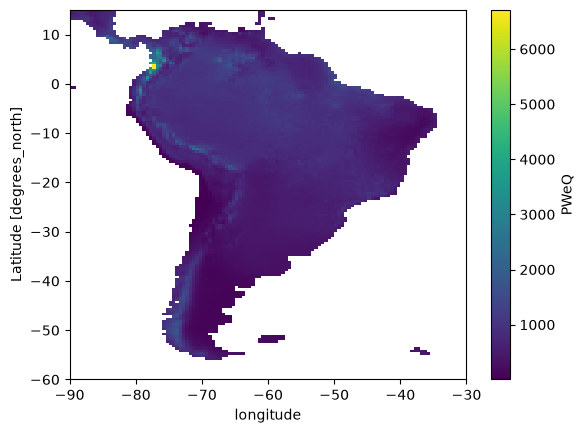

In [28]:
bio16 = PWeQ(P)
bio16.plot()

# Bioclim 17

In [29]:
def PDQ(P):
    """
    Calculate Precipitation of the driest quarter (bio17)
    
    Parameters:
  
    P (xarray.Dataset): Dataset containing precipitation data with variable "pr" for total monthly precipitaiton in mm. 
                        Expected dimensions are (month, latitude, longitude).
    
    Returns:
    xarray.DataArray: Precipitation of the driest quarter (PDQ)) calculated by identifying the quarter of minimal precipitation 
                      in the year. Dimensions are (latitude, longitude).
                      
    """
    
    # Determine the precipitation variable name (depends on scenario)
    pr_name = list(P.data_vars)[0]

    # Douple the P datset along the time axis (month) to enable rolling calculation (numerate month up to 24)
    P_douple = xr.concat([P, P], dim="month")
    P_douple = P_douple.assign_coords(month=np.arange(1, 25))
    
    # Calculate rolling sum over 3 months (quarterly sum) and shift by -1 to get the correct month 
    P_rolling = P_douple.rolling(month=3, center=True).sum().shift(month=-1).sel(month=np.arange(1,13))

    # Get the month index of the driest quarter
    min_months = P_rolling.idxmin(dim="month").fillna(1).astype(int)

    # Select the precipitation mean of the driest quarter
    P_select = P_rolling.sel(month=min_months[pr_name])

    return P_select[pr_name].rename("PDQ")

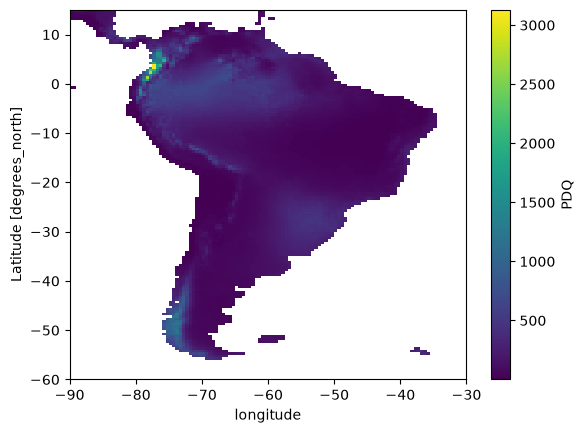

In [30]:
bio17 = PDQ(P)
bio17.plot()

# Bioclim 18

In [31]:
def PWaQ(T,P):
    """
    Calculate Precipitation of the warmest quarter (bio18)
    
    Parameters:
    T (xarray.Dataset): Dataset containing temperature data with variable 'Tavg' for average monthly temperature.
                        Expected dimensions are (month, latitude, longitude).
    P (xarray.Dataset): Dataset containing precipitation data with variable "pr" for total monthly precipitaiton in mm. 
                        Expected dimensions are (month, latitude, longitude).
    
    Returns:
    xarray.DataArray: Precipitation of the warmest quarter (PWaQ) calculated by first identifying the quarter of maximal mean temperature
                      in the year and secondly calculating the precipitation sum for that quarter. Dimensions are (latitude, longitude).
                      
    """
    
    # Determine the precipitation variable name (depends on scenario)
    pr_name = list(P.data_vars)[0]
    T_name = "Tavg"

    # Douple the P datset along the time axis (month) to enable rolling calculation (numerate month up to 24)
    P_douple = xr.concat([P, P], dim="month")
    P_douple = P_douple.assign_coords(month=np.arange(1, 25))

    T_douple = xr.concat([T, T], dim="month")
    T_douple = T_douple.assign_coords(month=np.arange(1, 25))
    
    # Calculate rolling sum over 3 months (quarterly sum) and shift by -1 to get the correct month
    T_rolling_sum = T_douple.rolling(month=3, center=True).sum().shift(month=-1).sel(month=np.arange(1,13))
    # Calculate rolling sum over 3 months (quarterly sum) and shift by -1 to get the correct month 
    P_rolling = P_douple.rolling(month=3, center=True).sum().shift(month=-1).sel(month=np.arange(1,13))

    # Get the month index of the warmest quarter
    max_months = T_rolling_sum.idxmax(dim="month").fillna(1).astype(int)

    # Select the precipitation of the warmest quarter
    P_select = P_rolling.sel(month=max_months[T_name])

    return P_select[pr_name].rename("PWaQ")

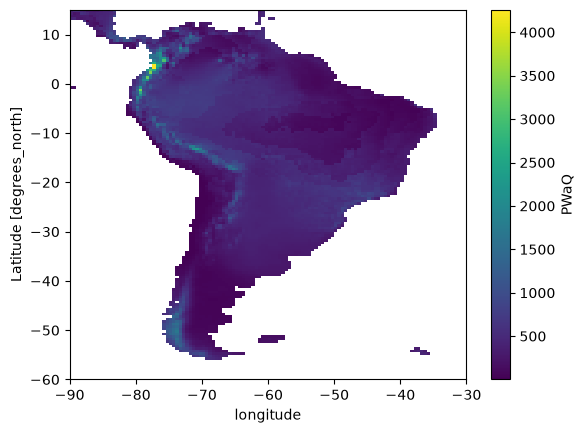

In [32]:
bio18 = PWaQ(T,P)
bio18.plot()

# Bioclim 19


In [33]:
def PCQ(T,P):
    """
    Calculate Precipitation of the coldest quarter (bio19)
    
    Parameters:
    T (xarray.Dataset): Dataset containing temperature data with variable 'Tavg' for average monthly temperature.
                        Expected dimensions are (month, latitude, longitude).
    P (xarray.Dataset): Dataset containing precipitation data with variable "pr" for total monthly precipitaiton in mm. 
                        Expected dimensions are (month, latitude, longitude).
    
    Returns:
    xarray.DataArray: Precipitation of the coldest quarter (PCQ) calculated by first identifying the quarter of minimal mean temperature
                      in the year and secondly calculating the precipitation sum for that quarter. Dimensions are (latitude, longitude).
                      
    """
    
    # Determine the precipitation variable name (depends on scenario)
    pr_name = list(P.data_vars)[0]
    T_name = "Tavg"

    # Douple the P datset along the time axis (month) to enable rolling calculation (numerate month up to 24)
    P_douple = xr.concat([P, P], dim="month")
    P_douple = P_douple.assign_coords(month=np.arange(1, 25))

    T_douple = xr.concat([T, T], dim="month")
    T_douple = T_douple.assign_coords(month=np.arange(1, 25))
    
    # Calculate rolling sum over 3 months (quarterly sum) and shift by -1 to get the correct month
    T_rolling_sum = T_douple.rolling(month=3, center=True).sum().shift(month=-1).sel(month=np.arange(1,13))
    # Calculate rolling sum over 3 months (quarterly sum) and shift by -1 to get the correct month 
    P_rolling = P_douple.rolling(month=3, center=True).sum().shift(month=-1).sel(month=np.arange(1,13))

    # Get the month index of the coldest quarter
    min_months = T_rolling_sum.idxmin(dim="month").fillna(1).astype(int)

    # Select precipitation of the coldest quarter
    P_select = P_rolling.sel(month=min_months[T_name])

    return P_select[pr_name].rename("PCQ")

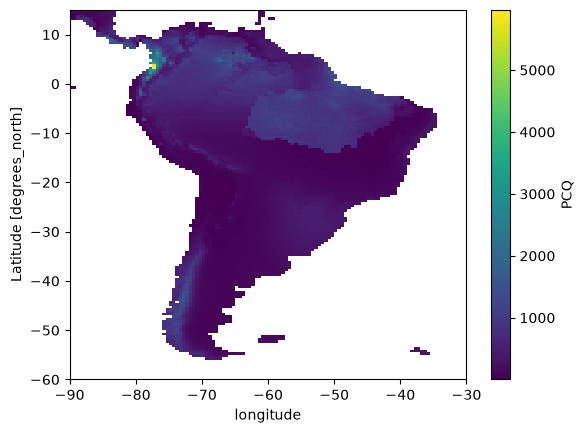

In [34]:
bio19 = PCQ(T,P)
bio19.plot()


In [35]:
# Check P values for belem
lat_belem = -1.45
lon_belem = -48.5

P_belem = P.sel(latitude=lat_belem, longitude=lon_belem, method="nearest")
P_belem.pr

<xarray.DataArray 'pr' (month: 12)> Size: 96B
array([297.2349432 , 351.25009084, 437.54863121, 419.94074826,
       292.09203379, 139.3323692 , 101.79617693,  58.23260188,
        38.19743339,  35.03323985,  47.29979444, 136.66539537])
Coordinates:
  * month      (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
    longitude  float64 8B -48.25
    latitude   float64 8B -1.25

In [36]:
# Full function 

def calculate_bioclimatic_variables_historic(T, P):
    """
    Calculate a set of bioclimatic variables from temperature and precipitation datasets for historic ERA5 climate data.

    Parameters:
    T (xarray.Dataset): Dataset containing temperature data with variable 'Tavg' for average monthly temperature.
                        Expected dimensions are (month, latitude, longitude).
    P (xarray.Dataset): Dataset containing precipitation data with variable "pr" for total monthly precipitaiton in mm/month. 
                        Expected dimensions are (month, latitude, longitude).

    Returns:
    xarray.Dataset: Dataset containing the calculated bioclimatic variables with dimensions (latitude, longitude).
    """
    bio1 = MAT(T).reset_coords(drop=True)
    bio4 = TS(T).reset_coords(drop=True)
    bio8 = MTWeQ(T,P).reset_coords(drop=True)
    bio9 = MTDQ(T,P).reset_coords(drop=True)
    bio10 = MTWaQ(T).reset_coords(drop=True)
    bio11 = MTCQ(T).reset_coords(drop=True)
    bio12 = AP(P).reset_coords(drop=True)
    bio13 = PWM(P).reset_coords(drop=True)
    bio14 = PDM(P).reset_coords(drop=True)
    bio15 = PS(P).reset_coords(drop=True)
    bio16 = PWeQ(P).reset_coords(drop=True)
    bio17 = PDQ(P).reset_coords(drop=True)
    bio18 = PWaQ(T,P).reset_coords(drop=True)
    bio19 = PCQ(T,P).reset_coords(drop=True)

    bioclimatic_vars = xr.merge([bio1, bio4, bio8, bio9, bio10, bio11, bio12, bio13, bio14, bio15, bio16, bio17, bio18, bio19])

    return bioclimatic_vars


In [37]:
bioclimatic_vars = calculate_bioclimatic_variables_historic(T, P)
bioclimatic_vars.to_netcdf(Path("..") / "data" / "hist_bioclim_vars.nc")

c:\Users\Clemens\Anaconda\envs\amazon_tip_project\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
